In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# STEP 1 — LOAD DATA
# ============================================================

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

In [4]:
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

In [5]:
df = pd.read_csv(url, names=columns, na_values='?')

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [7]:
df.shape

(303, 14)

In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [9]:
df.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [11]:
# ============================================================
# STEP 2 — TARGET & ENCODING
# ============================================================
# (target binary + get_dummies codes)

# ============================================================
# STEP 3 — EDA
# ============================================================
# EDA Goal: understand feature distributions, class separation, and correlations
# — guides preprocessing decisions (outlier capping, feature selection, scaling)

# (correlation heatmap + distribution + boxplot codes)

In [12]:
df = df.dropna()

In [13]:
df.shape

(297, 14)

In [14]:
# Target has 5 severity levels (0-4); converting to binary (0=healthy, 1=diseased)
df["target"] = (df["target"] > 0).astype(int)

In [15]:
# Float types in ca/thal are due to '?' missing values — pandas cast to float after NaN conversion
# sex, fbs, exang are already binary (0/1) — no encoding needed
# cp, restecg, slope, thal are nominal categorical — numbers don't imply order/magnitude
categorical_cols  = ["cp", "restecg", "slope", "thal"]

In [16]:
# drop_first=False: Decision Tree doesn't suffer from dummy variable trap, keeping all categories avoids info loss
# apply one hot encoding
df = pd.get_dummies(df, columns = categorical_cols, drop_first = False, dtype=float)

In [17]:
df.shape

(297, 23)

In [18]:
df["target"].value_counts()

target
0    160
1    137
Name: count, dtype: int64

In [19]:
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,...,cp_4.0,restecg_0.0,restecg_1.0,restecg_2.0,slope_1.0,slope_2.0,slope_3.0,thal_3.0,thal_6.0,thal_7.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,1,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [20]:
df.describe()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,...,cp_4.0,restecg_0.0,restecg_1.0,restecg_2.0,slope_1.0,slope_2.0,slope_3.0,thal_3.0,thal_6.0,thal_7.0
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,...,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,131.693603,247.350168,0.144781,149.599327,0.326599,1.055556,0.676768,0.461279,...,0.478114,0.494949,0.013468,0.491582,0.468013,0.461279,0.070707,0.552189,0.060606,0.387205
std,9.049736,0.468500,17.762806,51.997583,0.352474,22.941562,0.469761,1.166123,0.938965,0.499340,...,0.500364,0.500818,0.115462,0.500773,0.499818,0.499340,0.256768,0.498108,0.239009,0.487933
min,29.000000,0.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,130.000000,243.000000,0.000000,153.000000,0.000000,0.800000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,61.000000,1.000000,140.000000,276.000000,0.000000,166.000000,1.000000,1.600000,1.000000,1.000000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,202.000000,1.000000,6.200000,3.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
print(f"\nTarget distribution:\n{df['target'].value_counts()}")


Target distribution:
target
0    160
1    137
Name: count, dtype: int64


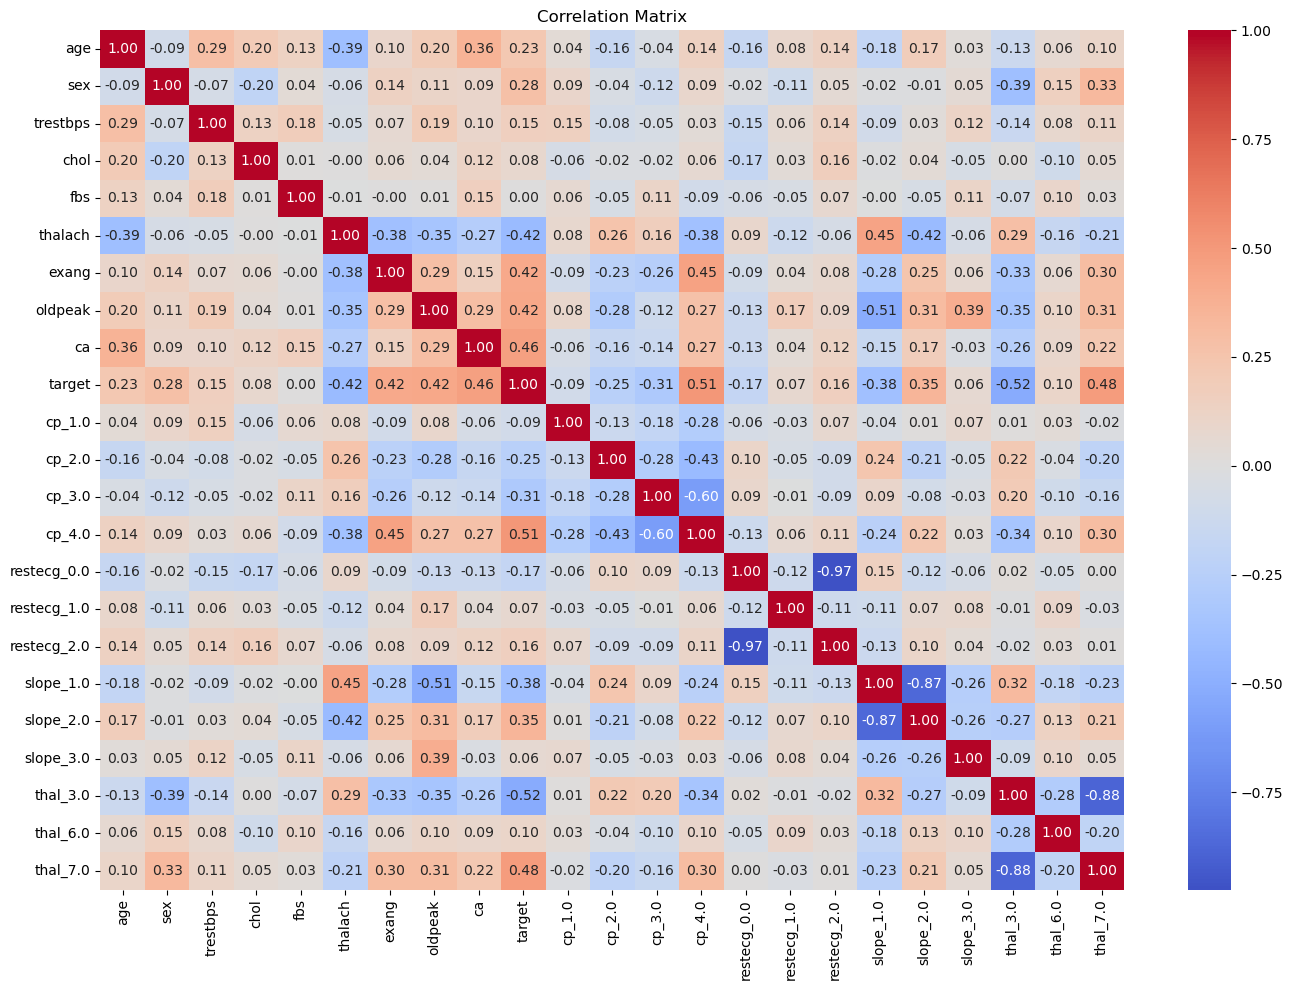

In [22]:
# Correlation heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [23]:
# Strong predictors: thal_3.0 (-0.52), cp_4.0 (+0.51), thal_7.0 (+0.48), thalach (-0.42)
# High inter-correlations (restecg, slope, thal dummies) — structural effect of one-hot encoding
# Decision Tree is immune to multicollinearity, but will flag in VIF step

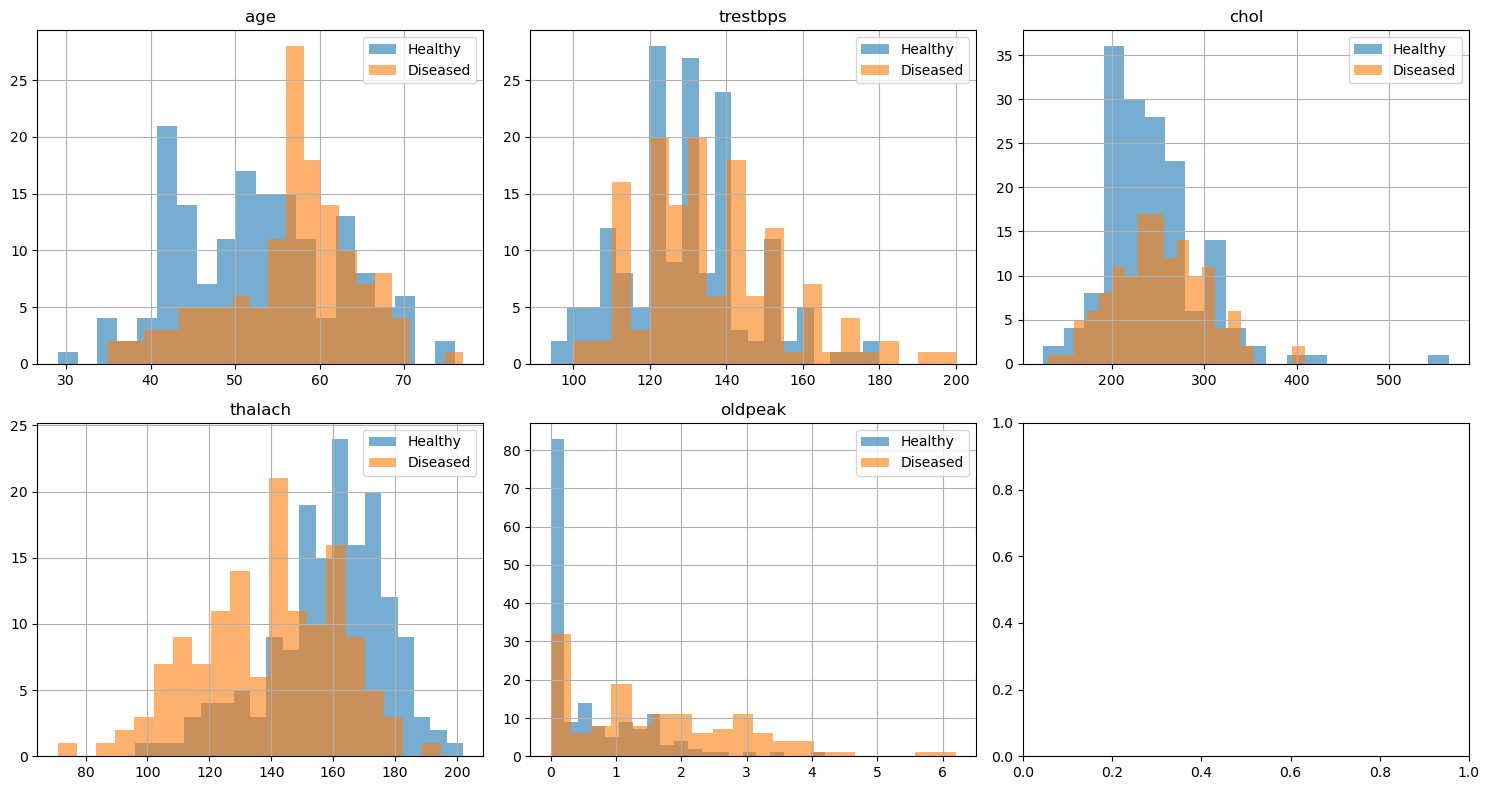

In [24]:
# Feature distributions by target
original_cols = ["age", "trestbps", "chol","thalach", "oldpeak"]
fig,axes = plt.subplots(2,3, figsize=(15,8))
for i , col in enumerate(original_cols):
    ax = axes[i//3][i%3]
    df[df["target"] == 0] [col].hist(ax=ax, alpha=0.6, label="Healthy", bins=20)
    df[df["target"] == 1] [col].hist(ax=ax, alpha=0.6, label="Diseased", bins=20)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

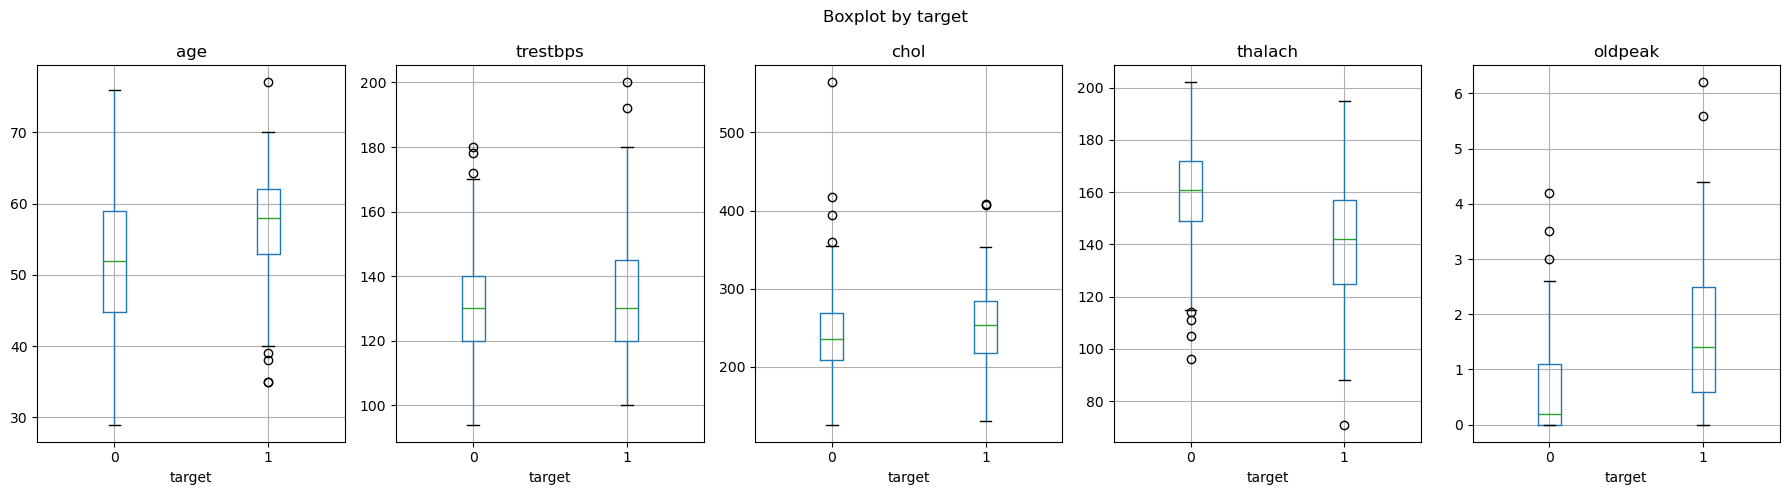

In [25]:
# Boxplot outlier check
fig,axes = plt.subplots(1,5, figsize=(18,5))
for i, col in enumerate(original_cols):
    df.boxplot(column=col, by="target", ax=axes[i])
plt.suptitle("Boxplot by target")
plt.tight_layout()
plt.show()

In [26]:
# thalach and oldpeak show strongest class separation
# age, trestbps, chol have outliers — will apply IQR capping
# chol and trestbps show weak separation — low predictive power expected
# thalach outliers retained — extreme values are physiologically valid and carry predictive signal

In [27]:
# ============================================================
# STEP 5 — MULTICOLLINEARITY CHECK (VIF)
# ============================================================

In [28]:
# VIF > 10 indicates high multicollinearity — but expected for one-hot encoded columns
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop("target",axis=1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))


        Feature       VIF
16    slope_1.0       inf
13  restecg_0.0       inf
10       cp_2.0       inf
11       cp_3.0       inf
12       cp_4.0       inf
9        cp_1.0       inf
18    slope_3.0       inf
19     thal_3.0       inf
20     thal_6.0       inf
17    slope_2.0       inf
21     thal_7.0       inf
14  restecg_1.0       inf
15  restecg_2.0       inf
7       oldpeak  1.866709
5       thalach  1.735684
0           age  1.502780
6         exang  1.434947
8            ca  1.377499
1           sex  1.342241
2      trestbps  1.226644
3          chol  1.150616
4           fbs  1.127052


In [29]:
# One-hot encoded columns show inf VIF — mathematically expected, not a data issue
# Numerical features all below 2 — no multicollinearity concern
# Decision Tree is not affected by multicollinearity — no columns dropped

In [30]:
# ============================================================
# STEP 6 — TRAIN/TEST SPLIT + SMOTE
# ============================================================

In [32]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [36]:
X = df.drop("target",axis=1)
y= df["target"]

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")

# 160/137 split — mild imbalance, but SMOTE applied for robustness
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train,y_train)
print(f"After SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")

Before SMOTE: {0: 128, 1: 109}
After SMOTE: {1: 128, 0: 128}


In [39]:
# SMOTE applied only on train set — prevents synthetic samples from leaking into test
# Test set remains original distribution — reflects real-world performance
# Mild imbalance (128/109) — SMOTE applied for balanced learning and consistency

In [41]:
# ============================================================
# STEP 7 — MODEL + HYPERPARAMETER TUNING
# ============================================================

In [43]:
from sklearn.tree import  DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Base model to see default performance
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sm,y_train_sm)
print(f"Default Depth: {dt.get_depth()}")


Default Depth: 11


In [48]:
# Hyper Parameter Tuning
param_grid = {
    "max_depth": [3,4,5,6,7,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf": [1,2,4],
    "criterion": ["gini","entropy"]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train_sm,y_train_sm)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

best_dt = grid_search.best_estimator_

Best Params: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV AUC: 0.8418


In [49]:
# Default depth=11 suggests overfitting — tuning reduced to 6
# min_samples_leaf=4 prevents overly specific leaves
# Optimized on ROC-AUC — more robust than accuracy for classification

In [50]:
# ============================================================
# STEP 8 — METRICS
# ============================================================

              precision    recall  f1-score   support

           0       0.71      0.91      0.79        32
           1       0.84      0.57      0.68        28

    accuracy                           0.75        60
   macro avg       0.77      0.74      0.74        60
weighted avg       0.77      0.75      0.74        60



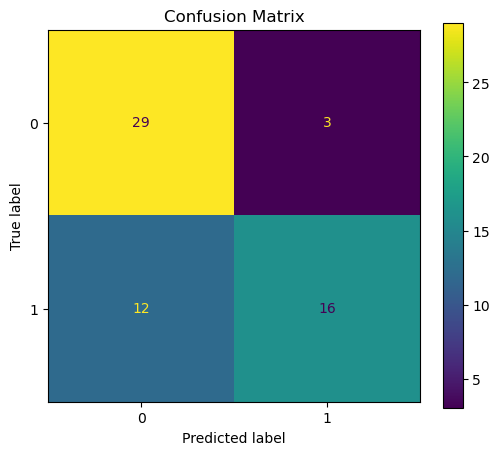

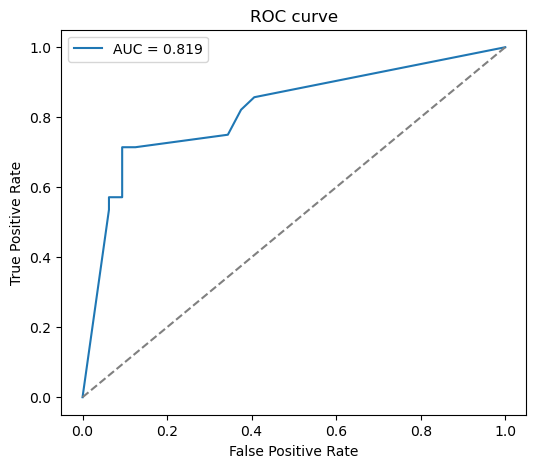

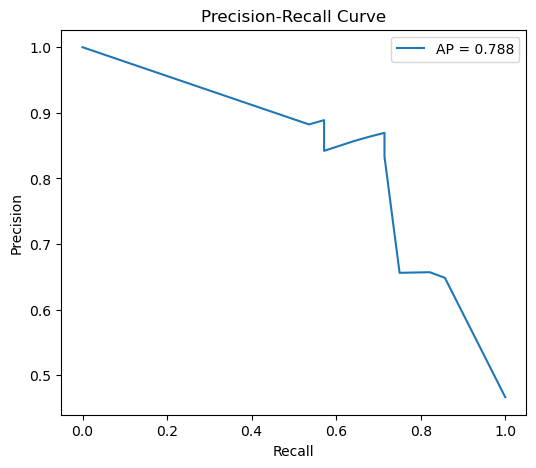

ROC-AUC 0.8192
Log loss: 9.0109
Cohen Kappa: 0.4875


In [56]:
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, precision_recall_curve,
                            log_loss, cohen_kappa_score, ConfusionMatrixDisplay,average_precision_score)

y_pred = best_dt.predict(X_test)
y_prob = best_dt.predict_proba(X_test)[:,1]

#Classification Report
print(classification_report(y_test,y_pred))


# Confusion Matrix
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot(ax=ax)
plt.title("Confusion Matrix")
plt.show()

#ROC- AUC
fpr, tpr, thresholds = roc_curve(y_test,y_prob)
auc = roc_auc_score(y_test,y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.show()

# precision recall

precision, recall, _ = precision_recall_curve(y_test,y_prob)
ap = average_precision_score(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# Additional Metrics
print(f"ROC-AUC {auc:.4f}")
print(f"Log loss: {log_loss(y_test,y_pred):.4f}")
print(f"Cohen Kappa: {cohen_kappa_score(y_test,y_pred):.4f}")


In [57]:
# Log Loss = 9.01 — high because DecisionTree probability estimates are poorly calibrated (leaf ratio based)

In [58]:
# ============================================================
# STEP 9 — THRESHOLD TUNING
# ============================================================

Best Threshold (F1): 0.34
              precision    recall  f1-score   support

           0       0.78      0.91      0.84        32
           1       0.87      0.71      0.78        28

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60

Cohen Kappa: 0.6275


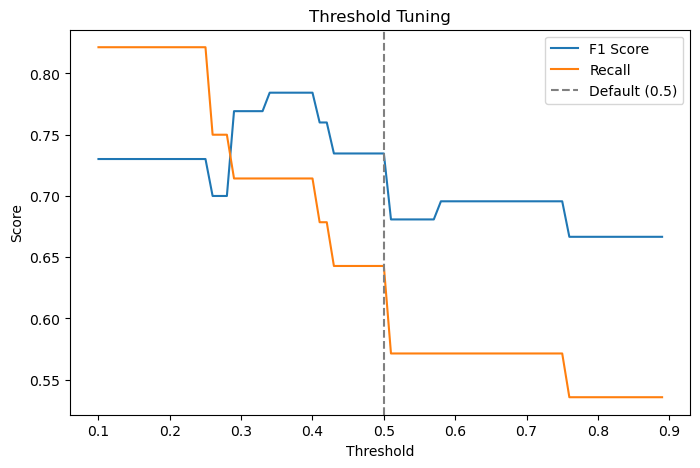

In [67]:
# Default threshold 0.5 — lowering it increases recall (catch more patients)
from sklearn.metrics import f1_score,recall_score

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []
recall_scores = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test,y_pred_t))
    recall_scores.append(recall_score(y_test,y_pred_t))

# Plot 
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, label="F1 Score")
plt.plot(thresholds, recall_scores, label="Recall")
plt.axvline(x=0.5, color="gray",linestyle="--", label="Default (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best Threshold (F1): {best_threshold:.2f}")

y_pred_tuned = (y_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_tuned))
print(f"Cohen Kappa: {cohen_kappa_score(y_test,y_pred_tuned):.4f}")

In [70]:
# ============================================================
# STEP 10 — FEATURE IMPORTANCE
# ============================================================

        Feature  Importance
12       cp_4.0    0.417694
8            ca    0.196087
21     thal_7.0    0.118124
7       oldpeak    0.091340
17    slope_2.0    0.056752
0           age    0.042040
3          chol    0.038993
2      trestbps    0.025501
5       thalach    0.013469
1           sex    0.000000
4           fbs    0.000000
10       cp_2.0    0.000000
9        cp_1.0    0.000000
6         exang    0.000000
13  restecg_0.0    0.000000
11       cp_3.0    0.000000
15  restecg_2.0    0.000000
14  restecg_1.0    0.000000
16    slope_1.0    0.000000
18    slope_3.0    0.000000
19     thal_3.0    0.000000
20     thal_6.0    0.000000


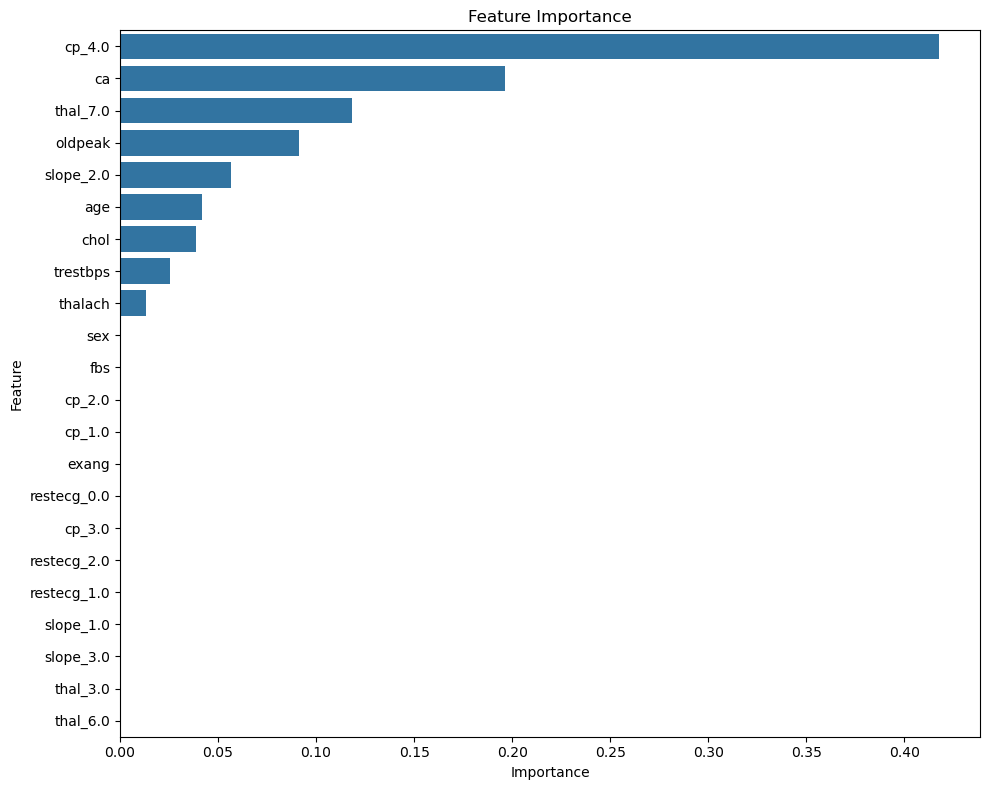

In [71]:
# Features ranked by how much they reduce Gini impurity across all splits

importances = best_dt.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "Feature" : feature_names,
    "Importance" : importances
}).sort_values("Importance", ascending=False)

print(feat_imp)

plt.figure(figsize=(10,8))
sns.barplot(data=feat_imp, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [72]:
# cp_4.0 dominates — asymptomatic chest pain is strongest predictor
# thal_3.0 excluded despite high correlation — model chose thal_7.0 (they're -0.88 correlated)
# Zero-importance features: model couldn't use them within max_depth=6 constraint

In [73]:
# ============================================================
# STEP 11 — CROSS VALIDATION
# ============================================================

CV ROC-AUC: 0.8138 ±  0.0561
CV F1: 0.7336 ± 0.0672


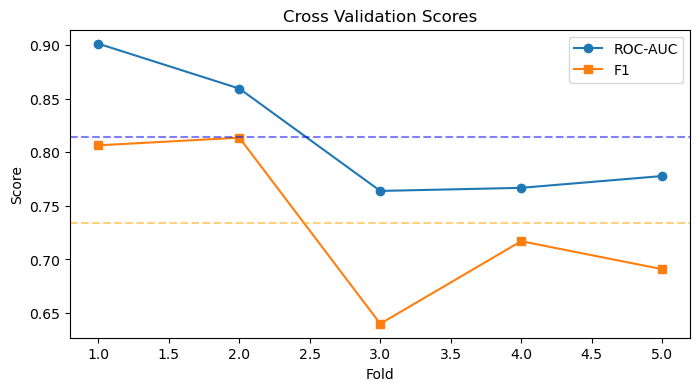

In [74]:
# Stratified K-Fold — preserves class ratio in each fold

from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(best_dt, X, y, cv=cv, scoring= "roc_auc")
cv_f1 = cross_val_score(best_dt,X,y, cv=cv, scoring="f1")

print(f"CV ROC-AUC: { cv_auc.mean():.4f} ±  {cv_auc.std():.4f}")
print(f"CV F1: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

plt.figure(figsize=(8,4))
plt.plot(range(1,6), cv_auc,marker="o", label="ROC-AUC")
plt.plot(range(1,6), cv_f1, marker="s", label="F1")
plt.axhline(y=cv_auc.mean(),color="blue",linestyle="--", alpha=0.5)
plt.axhline(y=cv_f1.mean(), color="orange", linestyle="--", alpha=0.5)
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Cross Validation Scores")
plt.legend()
plt.show()

In [75]:
# ROC-AUC stable (0.81 ± 0.056) but F1 variance high — DT sensitive to data splits
# Fold 3 drop signals model instability — expected for single trees, will improve with ensemble

In [76]:
# ============================================================
# STEP 12 — OVERFIT KONTROLÜ
# ============================================================

In [82]:
# Compare train vs test performance — large gap signals overfitting
y_train_pred = best_dt.predict(X_train_sm)
y_train_prob = best_dt.predict_proba(X_train_sm)[:,1]

train_auc = roc_auc_score(y_train_sm,y_train_prob)
test_auc = roc_auc_score(y_test,y_prob)

train_f1 = f1_score(y_train_sm, y_train_pred)
test_f1 = f1_score(y_test, y_pred_tuned)

print(f"Train ROC-AUC: {train_auc:.4f} | test ROC-AUC: {test_auc:.4f} | Gap: {train_auc - test_auc:.4f} ")
print(f"Train F1:      {train_f1:.4f} | Test F1:      {test_f1:.4f} | Gap: {train_f1 - test_f1:.4f}")


Train ROC-AUC: 0.9718 | test ROC-AUC: 0.8192 | Gap: 0.1526 
Train F1:      0.8880 | Test F1:      0.7843 | Gap: 0.1037


In [83]:
# Train-Test gap: AUC 0.15, F1 0.10 — mild overfitting
# Controlled by max_depth=6 and min_samples_leaf=4
# Gap expected for single tree — will reduce significantly with ensemble methods

In [85]:
# ============================================================
# STEP 13 — TREE VISUALIZATION
# ============================================================

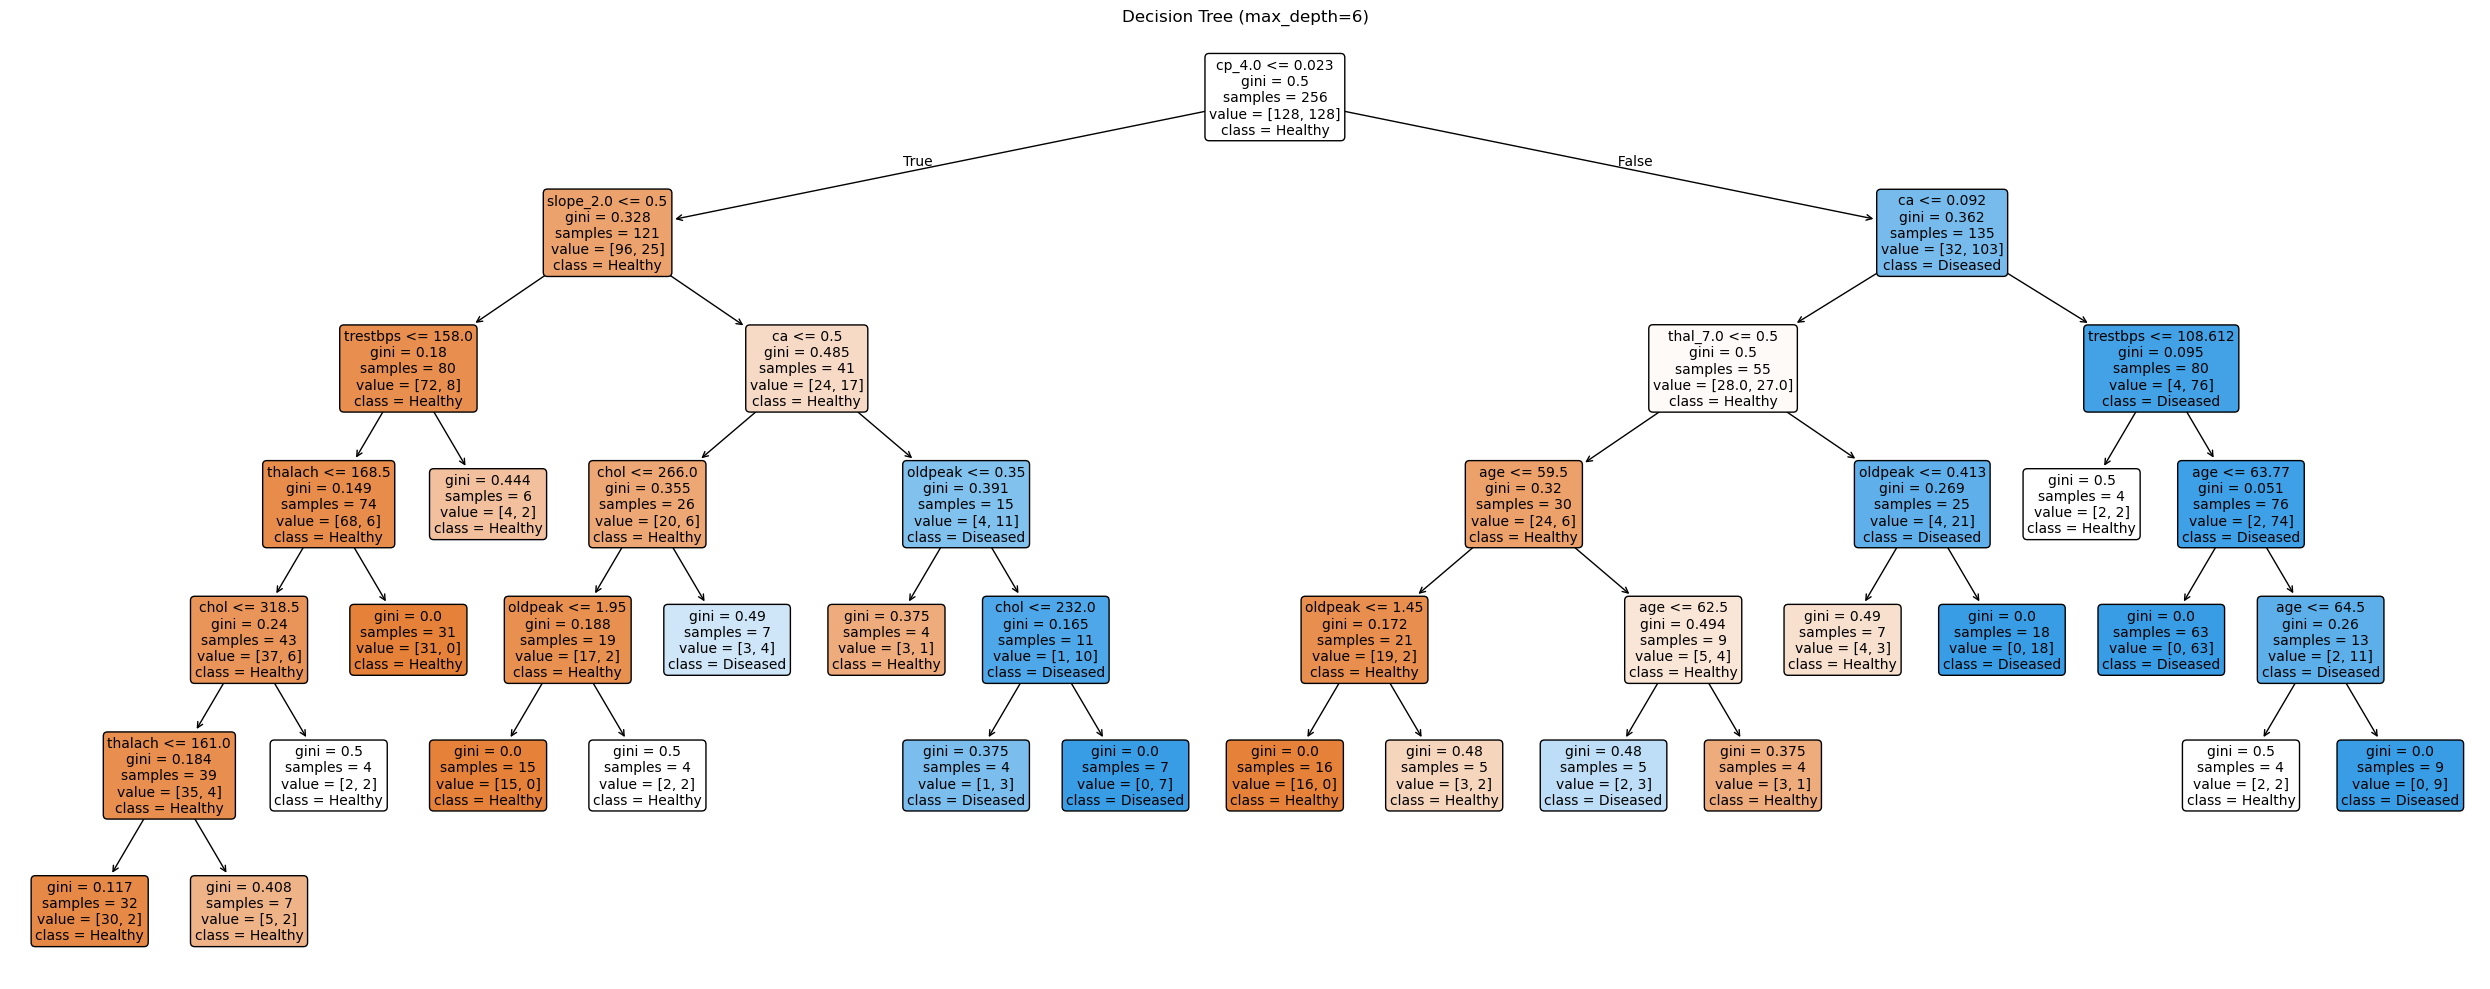

|--- cp_4.0 <= 0.02
|   |--- slope_2.0 <= 0.50
|   |   |--- trestbps <= 158.00
|   |   |   |--- thalach <= 168.50
|   |   |   |   |--- chol <= 318.50
|   |   |   |   |   |--- thalach <= 161.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- thalach >  161.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- chol >  318.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- thalach >  168.50
|   |   |   |   |--- class: 0
|   |   |--- trestbps >  158.00
|   |   |   |--- class: 0
|   |--- slope_2.0 >  0.50
|   |   |--- ca <= 0.50
|   |   |   |--- chol <= 266.00
|   |   |   |   |--- oldpeak <= 1.95
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- oldpeak >  1.95
|   |   |   |   |   |--- class: 0
|   |   |   |--- chol >  266.00
|   |   |   |   |--- class: 1
|   |   |--- ca >  0.50
|   |   |   |--- oldpeak <= 0.35
|   |   |   |   |--- class: 0
|   |   |   |--- oldpeak >  0.35
|   |   |   |   |--- chol <= 232.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |-

In [87]:
# Visualize the decision tree structure — shows splits and decision paths
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(25,10))
plot_tree(
    best_dt,
    feature_names= X.columns,
    class_names = ["Healthy", "Diseased"],
    filled=True,
    rounded = True,
    fontsize=10
)

plt.title("Decision Tree (max_depth=6)")
plt.tight_layout()
plt.show()

print(export_text(best_dt, feature_names=list(X.columns)))


In [90]:
# Tree visualization — root split on cp_4.0 confirms feature importance ranking
# Node color intensity indicates purity — darker = more samples of one class

In [92]:
# cp_4.0=1 + ca>0 → strong disease signal, cp_4.0=0 + normal slope → strong healthy